<h1 align="center" style="color:#A3B18A;">Deep Learning - Project</h1>
<h3 align="center" style="color:#A3B18A;">Group 13 - Rare Species Classification</h3>

---

### <span style="color:#A3B18A;">Group Members</span>

<table>
  <thead style="color:#A3B18A;">
    <tr>
      <th>Name</th>
      <th>Email</th>
      <th>Student ID</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Afonso Dias</td>
      <td>20211540@novaims.unl.pt</td>
      <td>20211540</td>
    </tr>
    <tr>
      <td>Inês Araújo</td>
      <td>20240532@novaims.unl.pt</td>
      <td>20240532</td>
    </tr>
    <tr>
      <td>Isabel Duarte</td>
      <td>20240545@novaims.unl.pt</td>
      <td>20240545</td>
    </tr>
    <tr>
      <td>Leonor Mira</td>
      <td>20240658@novaims.unl.pt</td>
      <td>20240658</td>
    </tr>
    <tr>
      <td>Rita Matos</td>
      <td>20211642@novaims.unl.pt</td>
      <td>20211642</td>
    </tr>
  </tbody>
</table>


---

<h2 style="color:#A3B18A;">Modelation Notebook - Custom CNN Architectures</h2>

<p><strong style="color:#A3B18A;">Description:</strong></p>

<p>
This notebook focuses on building, training, and evaluating deep learning models for the classification of species.
</p>

<p>Key steps include:</p>

<ul>
  <li><strong style="color:#A3B18A;">Model Definition:</strong> Design and implement convolutional neural network (CNN) architectures tailored for the dataset.</li>
  <li><strong style="color:#A3B18A;">Compilation and Training: </strong> Compile the models with appropriate loss functions, optimizers, and metrics. Train the models using the preprocessed dataset with callbacks for early stopping and learning rate adjustments.</li>
  <li><strong style="color:#A3B18A;">Evaluation:</strong> Assess the model's performance on validation and test datasets using metrics such as accuracy, loss, and F1 score.</li>
  <li><strong style="color:#A3B18A;">Visualization:</strong> Plot training history to analyze the model's learning behavior, including loss and F1 score curves.</li>
</ul>

<p>
This notebook ensures the development of robust models capable of accurately classifying rare species.
</p>

---

<a id="toc"></a>

<h2 style="color:#A3B18A;">Table of Contents</h2>

<ul style="list-style-type:none; padding-left:0;">
  <li><span style="color:#A3B18A;">1.</span> <a href="#chapter1">Import the Libraries</a></li>
  <li><span style="color:#A3B18A;">2.</span> <a href="#chapter2">Load the Data</a></li>
  <li><span style="color:#A3B18A;">3.</span> <a href="#chapter3">Data Augmentation</a>
    <ul style="list-style-type:none; padding-left:1em;">
      <li><span style="color:#A3B18A;">•</span> <a href="#chapter3-1">Data Augmentation 1.0</a></li>
      <li><span style="color:#A3B18A;">•</span> <a href="#chapter3-2">Data Augmentation 2.0</a></li>
    </ul>
  </li>
  <li><span style="color:#A3B18A;">4.</span> <a href="#chapter4">Model Definition</a></li>
  <li><span style="color:#A3B18A;">5.</span> <a href="#chapter5">Compilation and Training</a></li>
  <li><span style="color:#A3B18A;">6.</span> <a href="#chapter6">Evaluation and Visualization</a></li>
</ul>

---

<h2 id="chapter1" style="color:#A3B18A;">1. Import the Libraries</h2>

<p><a href="#toc" style="color:#A3B18A;">⬅ Back to Table of Contents</a></p>

<p>In this section, we import the necessary libraries required throughout this notebook.</p>

In [7]:
# Importing necessary libraries
import pandas as pd
import tensorflow as tf
import os
import random
import numpy as np
import PIL
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from functions import *

from tensorflow.keras import regularizers, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.metrics import Metric
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder

<h2 id="chapter2" style="color:#A3B18A;">2. Load the Data</h2>

<p><a href="#toc" style="color:#A3B18A;">⬅ Back to Table of Contents</a></p>

<p>This section loads the preprocessed data for training, validation, and testing. The data is organized into directories, and labels are extracted for further processing.</p>

In [ ]:
# Define directories for training, validation, and testing
split_dir = os.path.join("..","..", "data", "resized_data_256x256_split")     # Define the main directory for the dataset
train_dir, test_dir, val_dir = map(lambda dir: os.path.join(split_dir, dir), ['train', 'test', 'validation'])  

train_paths, train_labels, encoder = load_data(train_dir)

test_paths, test_labels, _ = load_data(test_dir, encoder=encoder)
val_paths, val_labels, _ = load_data(val_dir, encoder=encoder)

print(f"Loaded {len(train_paths)} training samples.")
print(f"Loaded {len(test_paths)} testing samples.")
print(f"Loaded {len(val_paths)} validation samples.")

Loaded 9584 training samples.
Loaded 1200 testing samples.
Loaded 1199 validation samples.


In [9]:
# Set random seeds for reproducibility
np.random.seed(42)              
tf.random.set_seed(42)

<h2 id="chapter3" style="color:#A3B18A;">3. Data Augmentation</h2>

<p><a href="#toc" style="color:#A3B18A;">⬅ Back to Table of Contents</a></p>

<p>Data augmentation is applied to artificially expand the training dataset by applying transformations such as rotations, flips, and zooms. This helps improve the model's generalization ability.</p>

<div style="border-left: 6px solid #A3B18A; padding: 10px; border-radius: 8px;">

<h2 id="chapter3-1" style="color:#A3B18A;">Data Augmentation 1.0</h2>

<p>In this version of data augmentation, we apply a series of transformations to artificially expand the training dataset. These transformations include:</p>

<ul>
  <li><strong>Rotation:</strong> Randomly rotate images up to 180 degrees.</li>
  <li><strong>Width and Height Shifts:</strong> Shift images horizontally and vertically by up to 25%.</li>
  <li><strong>Shear:</strong> Apply shear transformations to the images.</li>
  <li><strong>Zoom:</strong> Randomly zoom in or out by up to 25%.</li>
  <li><strong>Horizontal Flip:</strong> Flip images horizontally.</li>
  <li><strong>Fill Mode:</strong> Fill missing pixels using the nearest pixel values.</li>
</ul>

<p>These transformations help the model generalize better by exposing it to a variety of variations in the training data. The augmented images are normalized to have pixel values between 0 and 1.</p>

<p>As shown in the images below, this version of the data augmentation applies transformations that are overly aggressive. In some cases, the augmented outputs significantly distort the original image, making the primary content difficult to recognize or interpret.</p>

</div>

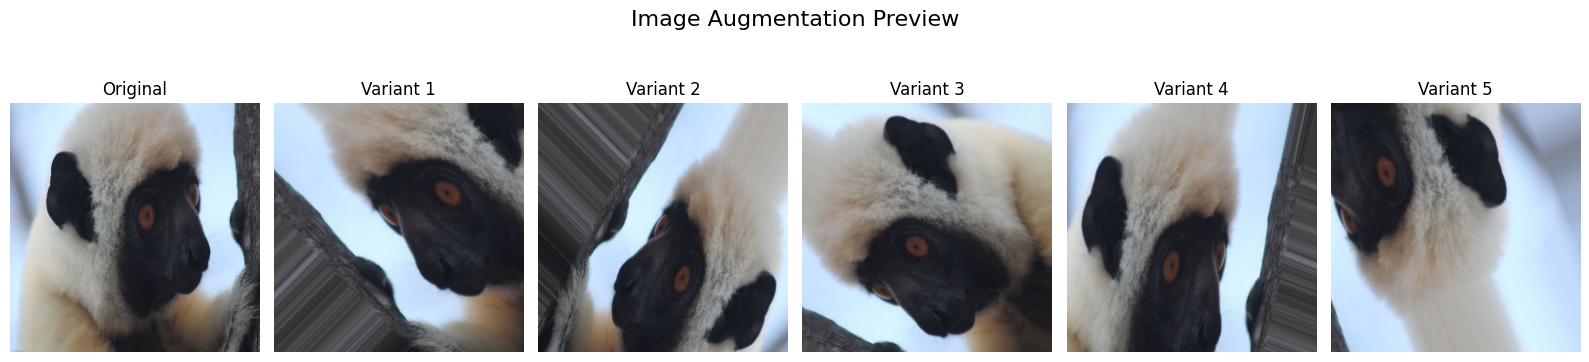

In [ ]:
# Create the training and validations data generators
train_datagen_2 = data_generator_2(augment=True)  

visualize_augmentations_custom(train_paths[5255], train_datagen_2)

<div style="border-left: 6px solid #A3B18A; padding: 10px; border-radius: 8px;">

<h2 id="chapter3-2" style="color:#A3B18A;">Data Augmentation 2.0</h2>

<p>This version of data augmentation introduces additional transformations to further enhance the diversity of the training dataset. The transformations include:</p>

<ul>
  <li><strong>Rotation:</strong> Randomly rotate images up to 45 degrees.</li>
  <li><strong>Width and Height Shifts:</strong> Shift images horizontally and vertically by up to 10%.</li>
  <li><strong>Shear:</strong> Apply shear transformations to the images.</li>
  <li><strong>Zoom:</strong> Randomly zoom in or out by up to 20%.</li>
  <li><strong>Horizontal Flip:</strong> Flip images horizontally.</li>
  <li><strong>Brightness Adjustment:</strong> Adjust the brightness of images within a range of 0.8 to 1.2.</li>
  <li><strong>Fill Mode:</strong> Fill missing pixels using the nearest pixel values.</li>
</ul>

<p>By including brightness adjustments, this version of augmentation introduces variations in lighting conditions, making the model more robust to real-world scenarios.</p>

<p>As illustrated in the images below, this augmentation approach is more balanced compared to the previous one. It introduces meaningful variation without overly distorting the original content, ensuring that key features remain visible across all augmented samples. For this reason, we selected this version to enhance our dataset.</p>

</div>

Found 9584 images belonging to 202 classes.
Found 1199 images belonging to 202 classes.


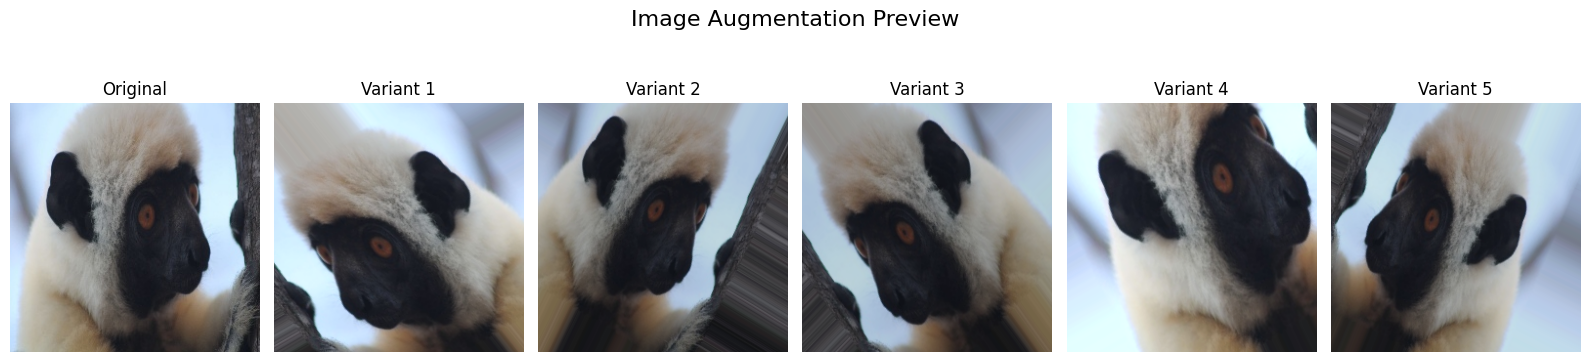

In [ ]:
# Create the training and validations data generators
train_datagen = data_generator(augment=True)  
validation_datagen = data_generator(augment=False)   

# Create the training and validation generators
train_generator = generator_custom(train_datagen, train_dir)          
validation_generator = generator_custom(validation_datagen, val_dir)   

visualize_augmentations_custom(train_paths[5255], train_datagen)

<div style="border-left: 6px solid #A3B18A; padding: 10px; border-radius: 8px;">

<h2 id="chapter3-3" style="color:#A3B18A;">Class Weights</h2>

<p>During the exploratory data analysis, we identified a strong imbalance in the class distribution of our dataset. While some classes had a large number of examples, others were significantly underrepresented. This imbalance can lead to biased learning, where the model favors the majority classes and performs poorly on the minority ones.</p>

<p>To address this, we computed the weights for each class based on their frequency in the dataset. These weights allow us to compensate for the imbalance by emphasizing the importance of minority classes during training.</p>

<p>Having the class weights calculated provided us the flexibility to experiment with different model configurations, both with and without applying these weights, to determine the most effective strategy for improving performance and fairness across all classes.</p>

</div>

In [12]:
labels = train_generator.classes
unique_classes = np.unique(labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=labels
)

# Map class indices to their corresponding computed weights
indexed_weights = enumerate(class_weights)

# Ensure all weights are standard float types in the final dictionary
class_weights_dict = {idx: float(weight) for idx, weight in indexed_weights}

class_weights_dict

{0: 0.3953795379537954,
 1: 1.976897689768977,
 2: 0.9884488448844885,
 3: 1.976897689768977,
 4: 1.976897689768977,
 5: 0.20450665756230796,
 6: 0.9884488448844885,
 7: 1.976897689768977,
 8: 1.976897689768977,
 9: 1.976897689768977,
 10: 1.976897689768977,
 11: 1.976897689768977,
 12: 1.976897689768977,
 13: 1.976897689768977,
 14: 1.976897689768977,
 15: 1.976897689768977,
 16: 1.976897689768977,
 17: 0.49942678478374153,
 18: 0.658965896589659,
 19: 0.9884488448844885,
 20: 1.976897689768977,
 21: 1.976897689768977,
 22: 1.976897689768977,
 23: 0.9884488448844885,
 24: 0.9884488448844885,
 25: 0.3294829482948295,
 26: 0.9884488448844885,
 27: 0.9884488448844885,
 28: 0.9884488448844885,
 29: 1.976897689768977,
 30: 0.3953795379537954,
 31: 1.976897689768977,
 32: 1.976897689768977,
 33: 1.976897689768977,
 34: 0.9884488448844885,
 35: 1.976897689768977,
 36: 0.24711221122112212,
 37: 1.976897689768977,
 38: 0.2824139556812824,
 39: 0.3953795379537954,
 40: 0.9884488448844885,
 41: 

<h2 id="chapter4" style="color:#A3B18A;">4. Model Definition</h2>

<p><a href="#toc" style="color:#A3B18A;">⬅ Back to Table of Contents</a></p>

<p>In this section, we define the architecture of the convolutional neural network (CNN). The model includes convolutional layers for feature extraction, pooling layers for dimensionality reduction, and dense layers for classification.</p>

<p>This notebook focuses on building custom CNN architectures from scratch. We began by designing a small and simple model to quickly experiment with different input image sizes, batch sizes, and data augmentation strategies. Once we identify the best-performing combination of these elements, we will use that setup to develop a deeper and more complex architecture aimed at improving performance.</p>

In [ ]:
# Simple CNN model
model = models.Sequential([
    
    # Input layer with input shape specified
    layers.InputLayer(input_shape=(256, 256, 3)),

    # Convolutional layer 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolutional layer 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(202, activation='softmax')
])

model.summary()
model_callbacks = callbacks("model_run")
model = model_compiler(model)

c:\Users\35191\anaconda3\anaconda\envs\Deep_Learning\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 262144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    33,554,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 202)            │        26,058 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,600,010 (128.17 MB)

 Trainable params: 33,600,010 (128.17 MB)

 Non-trainable params: 0 (0.00 B)

<h2 id="chapter5" style="color:#A3B18A;">5. Compilation and Training</h2>

<p><a href="#toc" style="color:#A3B18A;">⬅ Back to Table of Contents</a></p>

<p>The model is compiled with the Adam optimizer, categorical cross-entropy loss, and evaluation metrics such as accuracy and F1 score. Training is performed using the augmented dataset, with callbacks for early stopping and learning rate adjustments.</p>

In [ ]:
# Fit the model
model_run = model.fit(
    train_generator,
    validation_data=validation_generator,
    callbacks=model_callbacks,
    epochs=50
)

c:\Users\35191\anaconda3\anaconda\envs\Deep_Learning\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0277 - f1_score: 0.0034 - loss: 5.7620
Epoch 1: val_f1_score improved from -inf to 0.00952, saving model to ./Callbacks_256x192\history09\best_model_acc.weights.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.0278 - f1_score: 0.0034 - loss: 5.7584 - val_accuracy: 0.0592 - val_f1_score: 0.0095 - val_loss: 4.9127 - learning_rate: 0.0010
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0689 - f1_score: 0.0080 - loss: 4.8693
Epoch 2: val_f1_score improved from 0.00952 to 0.01144, saving model to ./Callbacks_256x192\history09\best_model_acc.weights.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.0689 - f1_score: 0.0080 - loss: 4.8690 - val_accuracy: 0.0792 - val_f1_score: 0.0114 - val_loss: 4.7512 - learning_rate: 0.0010
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0840 - f1_score: 0.0126 - loss: 4.6897
Epoch 3: val_f1_score improved from 0.01144 to 0.01829, saving mode

<h2 id="chapter6" style="color:#A3B18A;">6. Evaluation and Visualization</h2>

<p><a href="#toc" style="color:#A3B18A;">⬅ Back to Table of Contents</a></p>

<p>After training, the model's performance is evaluated on the validation and test datasets. Metrics such as accuracy, loss, and F1 score are analyzed. Training history is visualized to understand the model's learning behavior.</p>

<div style="border-left: 6px solid #A3B18A; padding: 10px; border-radius: 8px;">

<h2 id="chapter6-1" style="color:#A3B18A;">Results Visualization</h2>

<p> Visualizing results is essential for evaluating and understanding the performance of deep learning models. By analyzing key metrics across training, validation, and test datasets, we can gain deeper insights into the model’s learning behavior.

Plots such as loss, accuracy, and F1-score curves reveal important trends, convergence patterns, and potential issues like overfitting or underfitting. Additionally, visual tools like the confusion matrix highlight misclassifications, making it easier to identify problematic classes and guide further model refinement for improved performance.</p>

</div>

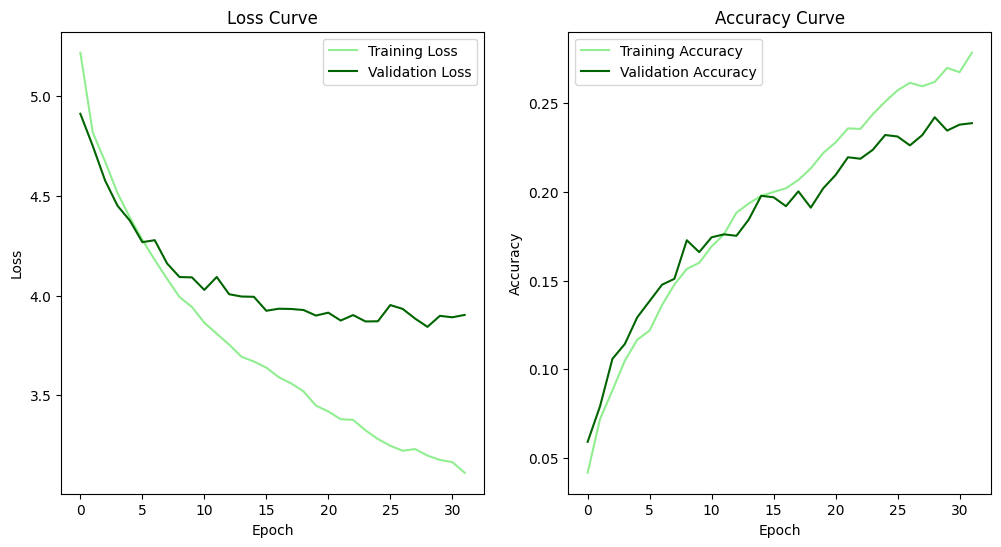

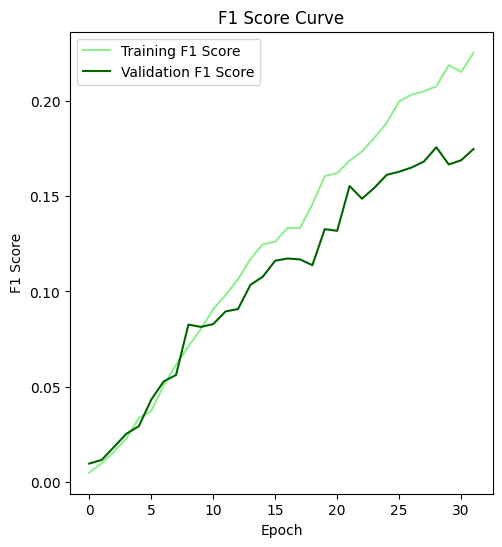

In [ ]:
acc, f1, loss, val_acc, val_f1, val_loss = metrics(model_run)

# Plotting the results
model_progress(model_run)

In [ ]:
# Get true labels from the generator
y_true = validation_generator.classes

# Get class names from the generator
class_names = list(validation_generator.class_indices.keys())

# Get predictions from the model
y_pred_probs = model.predict(validation_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 324ms/step


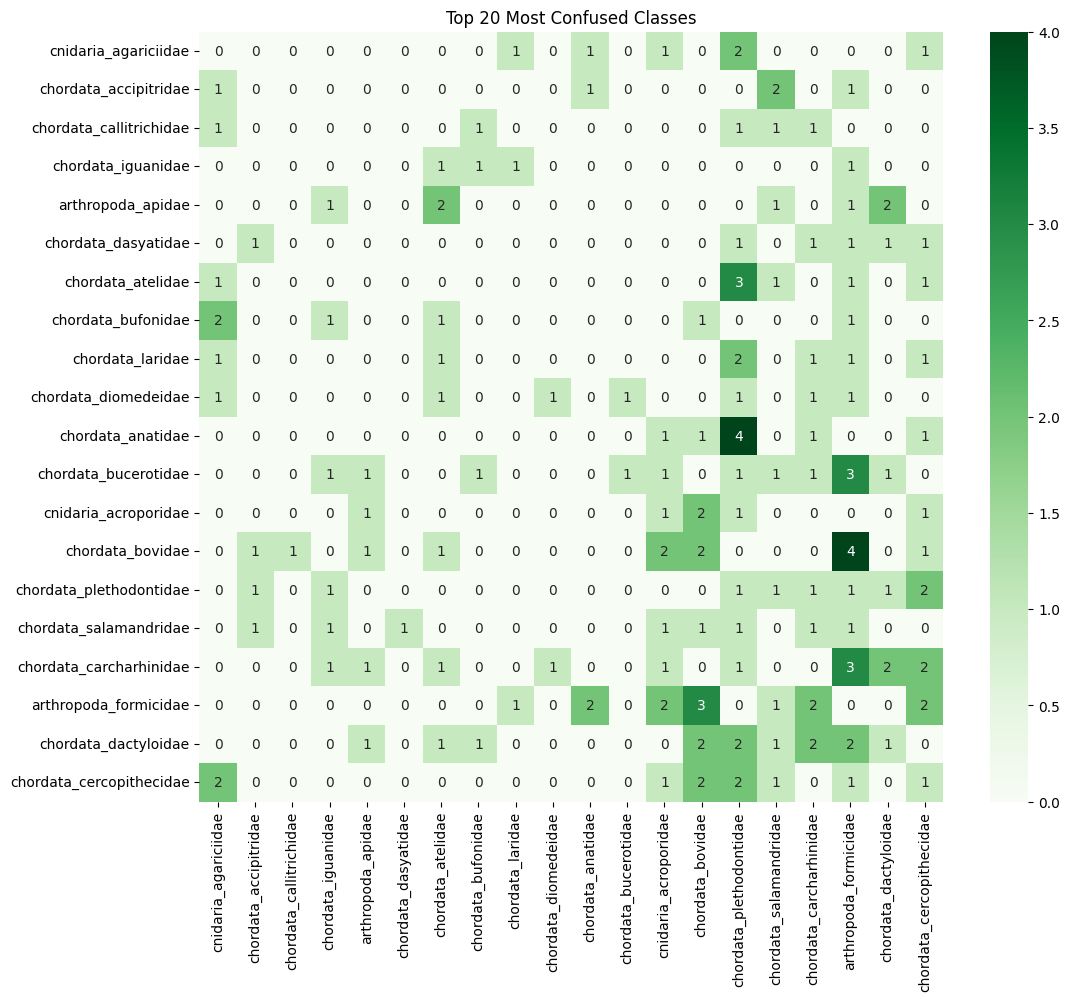

In [ ]:
cm_subset, subset_labels = get_most_confused_classes(y_true, y_pred, class_names, top_n=20)
plot_confusion_subset(cm_subset, subset_labels, title="Top 20 Most Confused Classes")

<div style="border-left: 6px solid #A3B18A; padding: 10px; border-radius: 8px;">

<h2 id="chapter6-1" style="color:#A3B18A;">Test Reports</h2>

<p> The test classification report is a crucial tool for assessing the performance of a deep learning model on unseen data. It presents important metrics such as precision, recall, F1-score, and support for each class, offering insight into how effectively the model differentiates between categories.

This report is instrumental in identifying the model's strengths and weaknesses, particularly in imbalanced datasets.  </p>

In [ ]:
# Create the test generator
test_datagen = data_generator(augment=False)
test_generator = generator_custom(test_datagen, test_dir)

Found 1200 images belonging to 202 classes.


In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy, test_f1_score = model.evaluate(test_generator)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Test F1 Score: {test_f1_score}")

c:\Users\35191\anaconda3\anaconda\envs\Deep_Learning\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - accuracy: 0.2796 - f1_score: 0.0860 - loss: 3.6292
Test Loss: 3.844369649887085
Test Accuracy: 0.1467326283454895
Test F1 Score: 0.2266666740179062


In [ ]:
# Generate predictions on the test set
test_predictions = model.predict(test_generator)
test_pred_classes = np.argmax(test_predictions, axis=1)

# Get the true classes
test_true_classes = test_generator.classes
test_class_labels = list(test_generator.class_indices.keys())

# Classification report for the test set
test_report = classification_report(test_true_classes, test_pred_classes, target_names=test_class_labels)
print("Test Classification Report:\n")
print(test_report)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 252ms/step
Test Classification Report:

                              precision    recall  f1-score   support

           arthropoda_apidae       0.71      0.80      0.75        15
      arthropoda_attelabidae       0.25      0.33      0.29         3
        arthropoda_carabidae       0.00      0.00      0.00         6
     arthropoda_cerambycidae       0.00      0.00      0.00         3
   arthropoda_coenagrionidae       0.50      0.67      0.57         3
       arthropoda_formicidae       0.43      0.83      0.57        30
        arthropoda_gomphidae       0.14      0.17      0.15         6
        arthropoda_lucanidae       0.00      0.00      0.00         3
      arthropoda_nymphalidae       0.33      0.33      0.33         3
      arthropoda_palinuridae       0.00      0.00      0.00         3
     arthropoda_papilionidae       0.33      1.00      0.50         3
       arthropoda_pisauridae       0.00      0.00      0.00         3
   arthropoda_platy

c:\Users\35191\anaconda3\anaconda\envs\Deep_Learning\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\35191\anaconda3\anaconda\envs\Deep_Learning\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\35191\anaconda3\anaconda\envs\Deep_Learning\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier